# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [4]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.plot import Plot

# frank1d
from frank.utilities import UVDataBinner

In [5]:
# frank1d
import frank
from frank.geometry import  SourceGeometry
from frank.radial_fitters import FrankFitter
from frank.utilities import UVDataBinner

## Functions

In [6]:
def run_plot(binning, x_lims = (1e5,8e6), y_lims_re = (-11, 17), y_lims_im = (-2, 2)):
    # Errors of visibilities
    binning = binning
    binning_re = binning.V.real*1e3
    binning_im = binning.V.imag*1e3
    binning_uv = binning.uv
    binning_re_err = binning.error.real*1e3
    binning_im_err = binning.error.imag*1e3

    x_lims = x_lims
    y_lims_re = y_lims_re
    y_lims_im = y_lims_im

    target_label = disk_name

    #Plot data
    fig, axs = plt.subplots(2,1,figsize=(12,5), gridspec_kw={'height_ratios': [3, 1]})
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0, hspace=0.05)

    #axs[0].plot(binned_vis0.uv, binned_vis0.V.real*1e3, c=cs[0], marker=ms[0], ls='None', alpha=0.5,
    #                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
    axs[0].errorbar(binning_uv, binning_re, binning_re_err, color='gray',fmt='x', alpha=0.7, capsize=2, linewidth=1, zorder=1, label='Data')
    #axs[0].plot(binning_uv / 1e6, vis_fit, color='r', linewidth=2, zorder=1.5, label='frank fit')
    axs[0].text(0.96, 0.88, target_label, ha='right', transform=axs[0].transAxes, fontsize=25)
    axs[0].plot(q, vis_model_1d_f2d.real*1e3, color = '#FA00FA', ls ='--', label = r'frank2d')
    axs[0].set_xscale('log')

    axs[1].errorbar(binning_uv, binning_im, binning_im_err, color='grey', fmt='x', alpha=0.7, capsize=2, linewidth=1, zorder=1)
    axs[1].plot(binning_uv, np.zeros(binning_uv.shape[0]), color='r', linestyle='dashed', zorder=1.5, linewidth=2)
    axs[1].plot(q, vis_model_1d_f2d.imag*1e3, color = '#FA00FA', ls ='--', label = r'frank2d')
    axs[1].set_xscale('log')

    axs[0].hlines(0,-10,10, alpha=1, linestyle=(0,(1,5)), color='k', linewidth=1, zorder=0)
    axs[1].hlines(0,-10,10, alpha=1, linestyle=(0,(1,5)), color='k', linewidth=1, zorder=0)


    axs[0].set_xlim(x_lims)
    axs[1].set_xlim(x_lims)
    axs[0].set_ylim(y_lims_re)
    axs[1].set_ylim(y_lims_im)

    axs[0].tick_params(which='major',axis='both',right=True,top=True, labelsize=15, pad=10,width=2.5, length=5,direction='in',color='k')
    axs[0].tick_params(which='minor',axis='both',right=True,top=True, labelsize=15, pad=10,width=1.5, length=3,direction='in',color='k')

    axs[1].tick_params(which='major',axis='both',right=True,top=True, labelsize=15, pad=10,width=2.5, length=5,direction='in',color='k')
    axs[1].tick_params(which='minor',axis='both',right=True,top=True, labelsize=15, pad=10,width=1.5, length=3,direction='in',color='k')

    axs[0].set_xlabel(r'Deprojected baseline (M$\lambda$)', fontsize = 15, labelpad=10)
    axs[0].set_ylabel('Re(V) (mJy)', fontsize = 15, labelpad=10)

    axs[1].set_xlabel(r'Deprojected baseline (M$\lambda$)', fontsize = 15, labelpad=10)
    axs[1].set_ylabel('Im(V) (mJy)', fontsize = 15, labelpad=15)

    handles, labels = axs[0].get_legend_handles_labels()
    order = [1, 0]  # frank fit second (index 0), Data first (index 1)
    axs[0].legend([handles[idx] for idx in order],[labels[idx] for idx in order],
                bbox_to_anchor=[0.98, 0.9], fontsize=12)

    # Hide x labels and tick labels for top plots and y ticks for right plots.
    for ax in axs.flat:
        ax.label_outer()
    
    for axis in ['top', 'bottom', 'left', 'right']:
        axs[0].spines[axis].set_linewidth(2)    
        axs[1].spines[axis].set_linewidth(2) 

In [7]:
from matplotlib.ticker import FuncFormatter

def sci_notation(x, pos):
    s = f"{x:.0e}"
    mantissa, exp = s.split('e')
    exp = int(exp)
    return rf"{mantissa}×10$^{{{exp}}}$" 

def float_notation(x, pos):
    s = f"{x:.0f}"
    return s

In [8]:
def calculate_resolution( clean_beam, intrinsic_resolution):
    bmaj_as = clean_beam['bmaj']
    bmin_as = clean_beam['bmin']
    final_bmaj_as = np.sqrt(bmaj_as**2 - intrinsic_resolution**2)
    final_bmin_as = np.sqrt(bmin_as**2 - intrinsic_resolution**2)
    print(f"-> Final beam to convolve with: {final_bmaj_as} x {final_bmin_as} arcsec")
    final_resolution = {'bmaj': final_bmaj_as, 'bmin': final_bmin_as, 'beam_pa': clean_beam['beam_pa']}
    return final_resolution

In [9]:
def edges(x):
    mids = (x[1:] + x[:-1]) / 2.0
    first = x[0]  - (x[1] - x[0]) / 2.0
    last  = x[-1] + (x[-1] - x[-2]) / 2.0
    return np.r_[first, mids, last]


In [10]:
def get_profile( x1, x2, f, bins, weighted = False, weights = None, fit_1d = False):
    from scipy.stats import binned_statistic
    
    if not fit_1d:
        r = np.hypot(x1, x2)
        r = r.ravel(order = 'C')
        f = f.ravel(order = 'C')
    else:
        r = x1

    if weighted:
        if weights is None:
            raise ValueError("Add weights.")
        F_W_binned, bin_edges, _ = binned_statistic(r, f*weights, 'sum', bins = bins)
        Weights_binned, bin_edges, _ = binned_statistic(r, weights, 'sum', bins = bins)

        f_1d = np.nan_to_num(F_W_binned, nan=0)
        f_1d = f_1d/Weights_binned
    else:
        f_1d, bin_edges, _ = binned_statistic(r, f, 'mean', bins = bins)
    
    r_1d = (bin_edges[:-1] + bin_edges[1:]) / 2
        
    return r_1d, f_1d

## Load data

In [11]:
# UVtable
dir = "../../data/uvtable/"
data_file = dir +"uvtable_SimulatedBlob.txt"

# Load data
file = np.loadtxt(data_file, unpack = True)
u, v, Re, Im, Weights = file
Vis = Re + Im*1j

In [12]:
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1

In [13]:
q_min = np.hypot(u,v).min()
q_max = np.hypot(u,v).max()
print(f"-> q_min data: {q_min}, q_max data: {q_max}")

-> q_min data: 11479.355483435862, q_max data: 8828201.715647701


In [14]:
Rmax = 3*rout
import math 
N = math.floor(5* Rmax/rad_to_arcsec * q_max)

print("N =", N)
print("Rmax =", Rmax)

N = 642
Rmax = 3


In [15]:
frank2d = Frank2D(N, Rmax)

In [16]:
q_min_f2d = np.unique(np.sort(np.hypot(frank2d.u, frank2d.v)))[1]
q_max_f2d = np.unique(np.sort(np.hypot(frank2d.u, frank2d.v)))[-1]
print(f"-> q_min frank2d: {q_min_f2d}, q_max frank2d: {q_max_f2d}")
print(f"-> q_min data: {q_min}, q_max data: {q_max}")

-> q_min frank2d: 48617.081072483736, q_max frank2d: 15606083.02426728
-> q_min data: 11479.355483435862, q_max data: 8828201.715647701


In [17]:
geom_f2d = Geometry(inc, pa, dra, ddec)

In [18]:
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

In [19]:
best_N50 = {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}

## Frank2D

In [20]:
start_time = time.time()

frank2d.fit(data = uvtable, kernel_params = best_N50, rtol = 1e-10 )

end_time = time.time()
print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = {N} took {end_time - start_time} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...
        +  Kernel = 0.05  min |  2.84 seconds
        +  Building system = 0.05  min |  2.90 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   1%|          | 279/50000 [00:53<2:40:02,  5.18 iterations/s]


            +  BiCGStab = 0.90  min |  54.00 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417657,
 'iterations': 279,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.42  min |  25.41 seconds
--> times building full visibility model = 0.42  min |  25.46 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = 642 took 91.14262914657593 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx


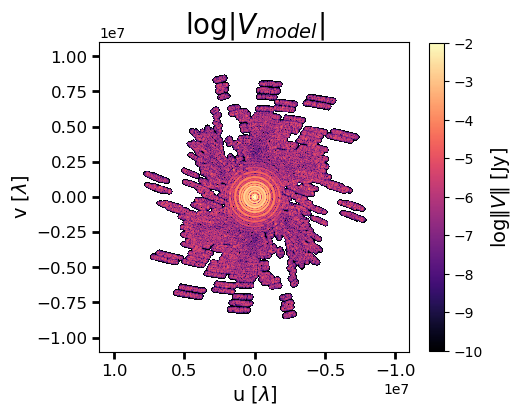

In [21]:
Plot(frank2d, geom_f2d).visibility(kind='model', fig_size = 5, title = r'log|$V_{model}$|', deproject = False)

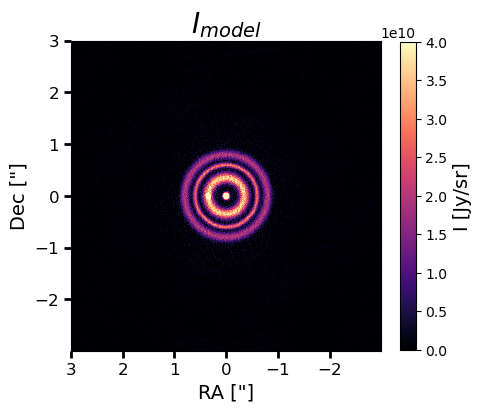

In [22]:
Plot(frank2d, geom_f2d).intensity(fig_size = 5, title = r'$I_{model}$', gamma = 1)

## 2D

In [23]:
imsize = N
cell =  2*Rmax/imsize
cell

0.009345794392523364

### Frank2d Vis Map

In [24]:
vis2d_f2d = frank2d.visibility_model

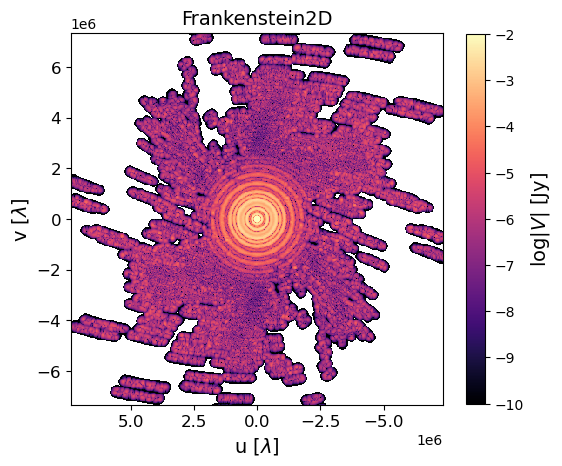

In [25]:
u_f2d, v_f2d = -frank2d.u_grid.reshape(imsize,imsize), -frank2d.v_grid.reshape(imsize,imsize)

plt.figure(figsize = (6, 6))
plt.pcolormesh( u_f2d, v_f2d,
                np.log(np.abs(vis2d_f2d.reshape(imsize,imsize))),
                cmap="magma",
                vmin=-10, vmax=-2)
zoom = 1.5
plt.xlabel(r'u [$\lambda$]', size=14)
plt.ylabel(r'v [$\lambda$]', size=14)
plt.title("Frankenstein2D", size=14)
cmap = plt.colorbar(shrink=0.8)
cmap.set_label(r'log|$V$| [Jy]', size=14)
plt.xlim(u_f2d.max()/zoom, u_f2d.min()/zoom)
plt.ylim(v_f2d.min()/zoom, v_f2d.max()/zoom)
plt.tick_params(axis='both', labelsize=12)
plt.gca().set_aspect(1)
plt.show()

### CLEAN .model

In [26]:
from astropy.io import fits
dir_  = "../../data/dotmodel_fits/"

disk = "SimulatedBlob_dotmodel_imsize642_cellsize0p009.fits"

fits_name = dir_ + disk
hdul = fits.open(fits_name)

In [27]:
import matplotlib.colors as colors

In [28]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS

In [29]:
hdr = hdul[0].header
data = hdul[0].data 

In [30]:
# beam
bmaj = hdr.get('BMAJ') # degrees
#bmaj_arsec = bmaj * 3600 # arcseconds
#bmin = hdr.get('BMIN')
#bmin_arsec = bmin * 3600 # arcseconds
bpa = hdr.get('BPA')

In [31]:
w = WCS(hdr)

In [32]:
data_squeezed = np.squeeze(data)   # (3000,3000) si los ejes 1 desaparecen
print("shape original:", data.shape, "-> squeezed:", data_squeezed.shape)

shape original: (1, 1, 642, 642) -> squeezed: (642, 642)


In [33]:
data = data_squeezed

In [34]:
if data.ndim == 3:
    # asumo (nz, ny, nx)
    nz, ny, nx = data.shape
    if channel_index is None:
        # elige el canal central por defecto
        ci = nz // 2
    else:
        ci = int(channel_index)
    img = data[ci, :, :].copy()
    # build a WCS for the 2D plane (drop the spectral axis)
    w2 = w.celestial  # WCS restringido a ejes celestes (RA/Dec)
else:
    ny, nx = data.shape
    img = data.copy()
    w2 = w.celestial

In [35]:
# pixel coordinates
x = np.arange(nx)
y = np.arange(ny)
xx, yy = np.meshgrid(x, y)

# wcs expects pixel coords in 1-based -> use wcs_pix2world with origin=0
ra_deg, dec_deg = w2.wcs_pix2world(xx, yy, 0)  # devuelve en grados

# reference coordinate (CRVAL)
crval_ra = w2.wcs.crval[0]
crval_dec = w2.wcs.crval[1]
refcoord = SkyCoord(crval_ra*u.deg, crval_dec*u.deg)

# compute offsets in arcsec from reference coordinate
coords = SkyCoord(ra_deg*u.deg, dec_deg*u.deg)
lon_off, lat_off = coords.spherical_offsets_to(refcoord)
# convertir a arcsec, y poner el eje x como RA offset (positivo hacia el Este)
ra_off_arcsec = -lon_off.to(u.arcsec).value
dec_off_arcsec = lat_off.to(u.arcsec).value

# extent of the image in arcsec (for imshow)
xmin = ra_off_arcsec.min()
xmax = ra_off_arcsec.max()
ymin = dec_off_arcsec.min()
ymax = dec_off_arcsec.max()

# we need to flip the y axis to match the imshow convention
img = np.flipud(img)



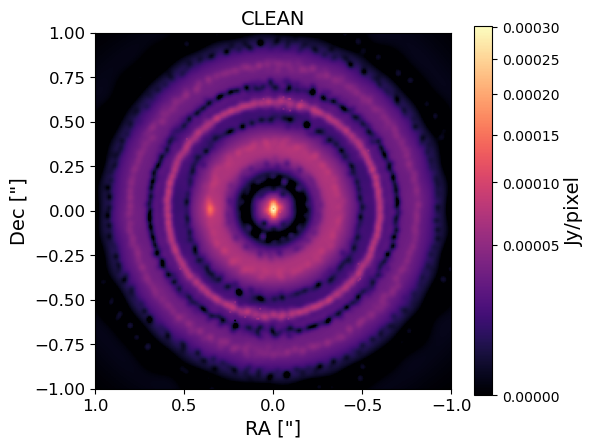

In [37]:
plt.figure(figsize=(6,5))
norm = colors.PowerNorm(gamma=0.5, vmin=0, vmax = img.max())
ax = plt.gca()
im = ax.imshow(
    img,
    extent=[xmax, xmin, ymin, ymax],
    aspect='equal',
    cmap='magma',
    norm=norm,
)
ax.set_xlabel('RA ["]', size=14)
ax.set_ylabel('Dec ["]', size=14)
ax.set_title(r'CLEAN', fontsize=14)
cbar = plt.colorbar(im, ax=ax, shrink=0.9)
cbar.set_label(hdr.get('BUNIT', 'Intensity'), size=14)
plt.tick_params(axis='both', labelsize=12)
plt.xlim(1, -1)
plt.ylim(-1, 1)
ax.grid(False)
plt.tight_layout()
plt.show()

In [38]:
# arcsecs per pixel
ra_off_arcsec[0][1] -ra_off_arcsec[0][0]

-0.00934582909954429

In [39]:
# img comes without the beam convolutded
Img_clean_model =  img/(frank2d.FT._dx * frank2d.FT._dy)
vis_clean = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img)))

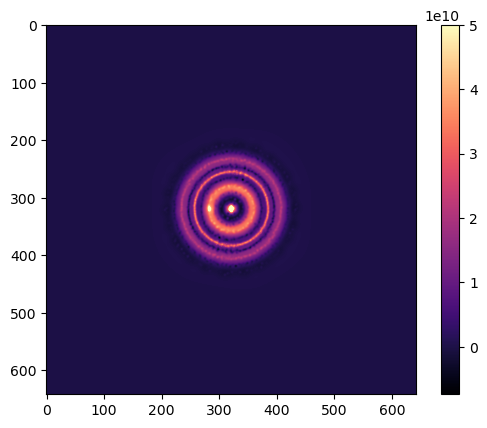

In [40]:
plt.imshow(Img_clean_model, cmap='magma', vmax=5e10)
plt.colorbar()

In [41]:
vis_clean2 = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img))) * (frank2d.FT._dx * frank2d.FT._dy)

In [42]:
vis_clean.shape

(642, 642)

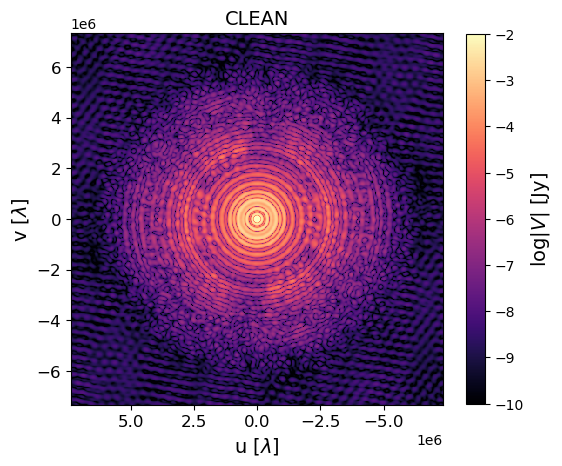

In [43]:
plt.figure(figsize = (6, 6))
plt.pcolormesh( u_f2d, v_f2d,
            np.log(np.abs(vis_clean.reshape(imsize, imsize))),
            cmap="magma",
            vmin=-10, vmax=-2)
zoom =1.5
plt.xlabel(r'u [$\lambda$]', size=14)
plt.ylabel(r'v [$\lambda$]', size=14)
plt.title("CLEAN", size=14)
cmap = plt.colorbar(shrink=0.8)
cmap.set_label(r'log|$V$| [Jy]', size=14)
plt.xlim(u_f2d.max()/zoom, u_f2d.min()/zoom)
plt.ylim(v_f2d.min()/zoom, v_f2d.max()/zoom)
plt.tick_params(axis='both', labelsize=12)
plt.gca().set_aspect(1)
plt.show()

### Difference

#### real part

In [44]:
diff_re = np.abs(((vis2d_f2d.real - vis_clean.real)/vis_clean.real)).reshape(imsize, imsize)

In [45]:
np.mean(np.abs(diff_re))

12.009529554240938

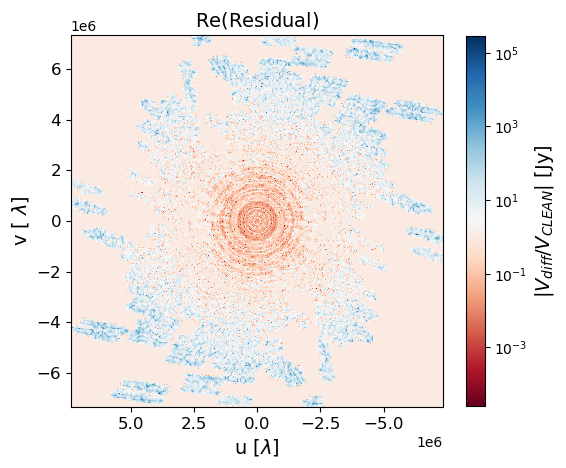

In [46]:
from matplotlib.colors import LogNorm

norm_re = colors.PowerNorm(gamma=0.1, vmin=diff_re.min(), vmax = diff_re.max())
norm_re_log = LogNorm(vmin=diff_re.min(), vmax = diff_re.max())


plt.figure(figsize = (6, 6))
plt.pcolormesh( u_f2d, v_f2d,
                diff_re,
                cmap="RdBu",
                norm=norm_re_log)
plt.xlabel(r'u [$\lambda$]', size=14)
plt.ylabel(r'v [ $\lambda$]', size=14)
plt.title(r'$\mathrm{Re}$(Residual)',  size=14)
cmap = plt.colorbar(shrink=0.8)
cmap.set_label(r'|$V_{diff}/V_{CLEAN}$| [Jy]', size=14)
plt.xlim(u_f2d.max()/1.5, u_f2d.min()/1.5)
plt.ylim(v_f2d.min()/1.5, v_f2d.max()/1.5)
plt.tick_params(axis='both', labelsize=12)
plt.gca().set_aspect(1)
plt.show()

### imag part

In [47]:
diff_im = (np.abs((vis2d_f2d.imag - vis_clean.imag)/vis_clean.imag)).reshape(imsize, imsize)

In [48]:
# put 0 the infinite values of diff_im
diff_im[np.isinf(diff_im)] = 0
np.median(np.abs(diff_im))

1.0

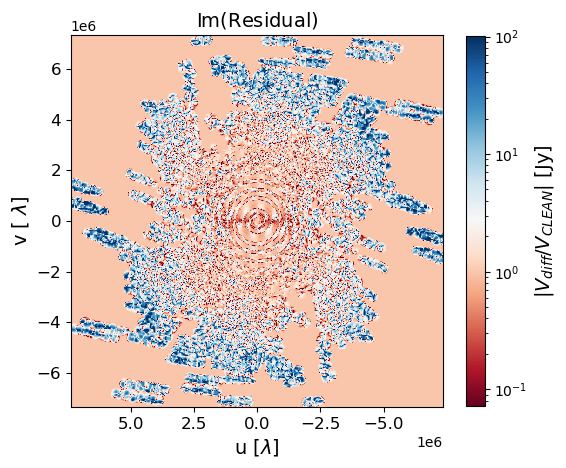

In [51]:
norm_im = colors.PowerNorm(gamma=0.2, vmin=diff_im.min(), vmax = diff_im.max())
norm_im_log = LogNorm(vmin=diff_im.min()*1e3, vmax = diff_im.max()/1e3)


plt.figure(figsize = (6, 6))
plt.pcolormesh( u_f2d, v_f2d,
                diff_im,
                cmap="RdBu",
                norm=norm_im_log)
plt.xlabel(r'u [$\lambda$]', size=14)
plt.ylabel(r'v [ $\lambda$]', size=14)
plt.title(r'$\mathrm{Im}$(Residual)',  size=14)
cmap = plt.colorbar(shrink=0.8)
cmap.set_label(r'|$V_{diff}/V_{CLEAN}$| [Jy]', size=14)
plt.xlim(u_f2d.max()/1.5, u_f2d.min()/1.5)
plt.ylim(v_f2d.min()/1.5, v_f2d.max()/1.5)
plt.tick_params(axis='both', labelsize=12)
plt.gca().set_aspect(1)
plt.show()